## MPRAnn: model to predict the activity from sequence
- bin the data to reduce data leakage
- use ultra mpra data for pretraining the model
- use pretraining on open chromatin data

In [24]:
import pandas as pd
import numpy as np
import yaml
import os
from collections import defaultdict
from importlib import reload
import math # check for nan
import matplotlib.pyplot as plt # plt.show()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [3]:
# from IGVF metadata
col_name = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

### Bin the data to reduce data leakage
- use groupK fold
- define group: goal: sequences of same gene or same region are in the same bin
- identify regions which are associated to multiple genes (they hold us back from using genes as group generators)

In [4]:
bcalm_result_all_elements = pd.read_csv(config['files']['creating']['all_element_BCalm_np_negative_neuron_vs_tested_unique'], sep="\t")
bcalm_result_all_elements
print(f'Number of elements with BCalm results: {bcalm_result_all_elements[col_name].nunique()}')
# get gene name and screen region
bcalm_result_all_elements['tmp_screen_region'] = bcalm_result_all_elements[col_name].apply(hf.get_region_info)
# bcalm_result_all_elements['tmp_gene_name'] = bcalm_result_all_elements[col_name].apply(lambda name: hf.get_gene_name(name, with_controls=False))
print(f'Number of unique screen regions: {bcalm_result_all_elements["tmp_screen_region"].nunique()}')

# gene_to_region_df = bcalm_result_all_elements.groupby(['tmp_gene_name']).agg(list)['tmp_screen_region'].to_frame().reset_index()
# gene_to_region_df # 523
# region_to_gene_df = bcalm_result_all_elements.groupby(['tmp_screen_region']).agg(list)['tmp_gene_name'].to_frame().reset_index()
# region_to_gene_df
bcalm_result_all_elements.head()

Number of elements with BCalm results: 63333
Number of unique screen regions: 24788


,logFC,AveExpr,t,P.Value,adj.P.Val,name,tmp_screen_region
0,2.056023,0.798601,60.235487,4.614527e-240,2.960127e-235,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,EH38E3192081
1,1.901706,0.643968,57.860927,9.922394e-233,3.182509e-228,cardiac_neuro_cava_random:RERE|ENSG00000142599...,EH38E1316374
2,2.088181,0.830374,56.439870,9.177149e-228,1.962319e-223,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,EH38E1918401
3,2.287976,1.030173,62.363797,7.643404e-227,1.225773e-222,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,EH38E1880427
4,1.768680,0.511044,53.848342,1.788233e-218,2.294231e-214,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,EH38E2924690


In [38]:
# # identify if the lists of genes are all the same gene
# def has_same_elements(lst):
#     if not lst:  # Check if the list is empty
#         return True

#     first_element = lst[0]
#     return all(element == first_element for element in lst)

# region_to_gene_df['single_gene'] = region_to_gene_df['tmp_gene_name'].apply(has_same_elements)
# region_to_gene_df['single_gene'].value_counts()

In [5]:
bcalm_result_all_elements.head()
bcalm_result_all_elements["name"].to_list()

['cardiac_neuro_cava_random:REF_WWOX|ENSG00000186153.18|EH38E3192081_fwd_tile1-1',
 'cardiac_neuro_cava_random:RERE|ENSG00000142599.20|EH38E1316374_rev_tile1-1',
 'cardiac_neuro_cava_random:TCF4|ENSG00000196628.20|EH38E1918401_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_PSMD12|ENSG00000197170.10|EH38E1880427_rev_tile1-1',
 'cardiac_neuro_cava_random:RBM20|ENSG00000203867.8|EH38E2924690_fwd_tile1-1',
 'cardiac_neuro_cava_random:ALT_PHACTR1|ENSG00000112137.19|EH38E2447178_fwd_tile1-1_PHACTR1|ENSG00000112137.19|EH38E2447178|6-13164515-C-T',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E3484163_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E3484163|22-42115723-G-T',
 'cardiac_neuro_cava_random:ALT_TRIO|ENSG00000038382.23|EH38E2358394_fwd_tile1-1_TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G',
 'cardiac_neuro_cava_random:ALT_WWOX|ENSG00000186153.18|EH38E3192081_fwd_tile1-1_WWOX|ENSG00000186153.18|EH38E3192081|16-78129977-T-C',
 'cardiac_neuro_cava_random:REF_NBEA|ENSG00

In [6]:
import re

def extract_genes(name):
    # Updated regex pattern to match gene names
    pattern = r'(?:REF_|ALT_)?([A-Z0-9]+)(?=\|ENSG)'

    # Find all matches
    matches = re.findall(pattern, name)

    # Return a set of unique gene names
    return list(set(matches))

bcalm_result_all_elements['tmp_gene_list'] = bcalm_result_all_elements[col_name].apply(extract_genes)

# bcalm_result_all_elements.head()
# bcalm_result_all_elements['assigned_gene_number'] = bcalm_result_all_elements['tmp_gene_list'].apply(lambda gene_list: len(gene_list)) # min 1 max 2


# seq1 | apol2 | apol4 | apol3 | ... | EH38E3478562
# seq2 | apol2 | NA | NA | EH38E3478561
# seq3 | GATA4 | NA | NA | EH38E3478562

# idx | seq1 | EH38E3478562 | set(genes)


# 1. set index and group index
bcalm_result_all_elements['seq_idx'] = bcalm_result_all_elements.index
bcalm_result_all_elements['group_idx'] = bcalm_result_all_elements.index
print(bcalm_result_all_elements.shape[0])
# 2. explode dataframe
bcalm_result_all_element_genes = bcalm_result_all_elements.explode('tmp_gene_list')
bcalm_result_all_element_genes

# 3. (set of genes) => row per gene (explode)
bcalm_result_all_element_genes_grouped = bcalm_result_all_element_genes.groupby('tmp_gene_list').agg(min).reset_index()
bcalm_result_all_element_genes_grouped
print('Number of current state of the sequence table with group information', bcalm_result_all_element_genes.shape[0])
bcalm_result_all_element_genes.drop(columns=['group_idx'], inplace=True)
bcalm_result_all_element_genes = bcalm_result_all_element_genes.merge(bcalm_result_all_element_genes_grouped[['tmp_gene_list', 'group_idx']], on='tmp_gene_list', how='inner')

# 4. groupby region_id get minimum idx (group id)
bcalm_result_all_element_region = bcalm_result_all_element_genes.groupby('tmp_screen_region').agg(min).reset_index()
bcalm_result_all_element_region
bcalm_result_all_element_genes.drop(columns=['group_idx'], inplace=True)
bcalm_result_all_element_genes = bcalm_result_all_element_genes.merge(bcalm_result_all_element_region[['tmp_screen_region', 'group_idx']], on='tmp_screen_region', how='inner')
print('Number of current state of the sequence table with group information', bcalm_result_all_element_genes.shape[0])

grouped = bcalm_result_all_element_genes.groupby('seq_idx')['group_idx'].nunique()

# Check if all groups have only one unique value
is_consistent = (grouped == 1).all()
if is_consistent:
    print('All names are associated to a group')

group_idx_df = bcalm_result_all_element_genes[['seq_idx', 'group_idx']].drop_duplicates(subset='seq_idx')

# drop group_idx
bcalm_result_all_elements.drop(columns=['group_idx'], inplace=True)

# add group info
bcalm_result_all_elements_group_idx = bcalm_result_all_elements.merge(group_idx_df, on='seq_idx', how='inner')
bcalm_result_all_elements_group_idx.drop(columns=['seq_idx', 'AveExpr', 't', 'P.Value', 'adj.P.Val'], inplace=True)
print('Shape of final table: ', bcalm_result_all_elements_group_idx.shape[0])

bcalm_result_all_elements_group_idx.head()


63333
Number of current state of the sequence table with group information 64192


/tmp/ipykernel_1728/299118195.py:35: FutureWarning: The provided callable <built-in function min> is currently using DataFrameGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  bcalm_result_all_element_genes_grouped = bcalm_result_all_element_genes.groupby('tmp_gene_list').agg(min).reset_index()
/tmp/ipykernel_1728/299118195.py:42: FutureWarning: The provided callable <built-in function min> is currently using DataFrameGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  bcalm_result_all_element_region = bcalm_result_all_element_genes.groupby('tmp_screen_region').agg(min).reset_index()


Number of current state of the sequence table with group information 64192
All names are associated to a group
Shape of final table:  63333


,logFC,name,tmp_screen_region,tmp_gene_list,group_idx
0,2.056023,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,EH38E3192081,[WWOX],0
1,1.901706,cardiac_neuro_cava_random:RERE|ENSG00000142599...,EH38E1316374,[RERE],1
2,2.088181,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,EH38E1918401,[TCF4],2
3,2.287976,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,EH38E1880427,[PSMD12],3
4,1.768680,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,EH38E2924690,[RBM20],4


In [7]:
bcalm_result_all_elements_group_idx['group_idx'].nunique()

513

In [9]:
# tmp for colab
def useGroupForSplit(data, group_col, x_cols, y_cols):
    """Function which uses groups to split train and test (e.g. regions associated to the same gene or different genes)"""
    # Step 1: First split into train (90%) and test (10%)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
    train_idx, test_idx = next(gss.split(data, groups=data[group_col]))

    train_df = data.iloc[train_idx]
    test_df = data.iloc[test_idx]

    # Step 2: Split the test set into test (50%) and validation (50%)
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    test_idx, val_idx = next(gss_test.split(test_df, groups=test_df[group_col]))

    final_test_df = test_df.iloc[test_idx]
    val_df = test_df.iloc[val_idx]

    x_train = np.array(train_df[x_cols].apply(one_hot_encode).tolist())
    y_train = train_df[y_cols]
    x_test = np.array(final_test_df[x_cols].apply(one_hot_encode).tolist())
    y_test = final_test_df[y_cols]
    x_val = np.array(val_df[x_cols].apply(one_hot_encode).tolist())
    y_val = val_df[y_cols]
    return x_train, x_test, x_val, y_train, y_test, y_val




#### Add BIN column (10 bins everyone has independend groups of the group ids)

In [10]:
# Step 1: Get unique group IDs and shuffle them
unique_groups = bcalm_result_all_elements_group_idx['group_idx'].unique()
np.random.shuffle(unique_groups)

# Step 2: Split the unique groups into 10 bins
group_bins = np.array_split(unique_groups, 10)

# Step 3: Create a dictionary mapping each group to its bin
group_to_bin = {group: bin_num for bin_num, bin_groups in enumerate(group_bins, 1) for group in bin_groups}

# Step 4: Create the new 'bin' column
bcalm_result_all_elements_group_idx['BIN'] = bcalm_result_all_elements_group_idx['group_idx'].map(group_to_bin)

# # Optional: If you want the bins to be numbered from 1 to 10 instead of 0 to 9
# bcalm_result_all_elements_group_idx['BIN'] = bcalm_result_all_elements_group_idx['BIN'] + 1

In [11]:
bcalm_result_all_elements_group_idx.head()

,logFC,name,tmp_screen_region,tmp_gene_list,group_idx,BIN
0,2.056023,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,EH38E3192081,[WWOX],0,7
1,1.901706,cardiac_neuro_cava_random:RERE|ENSG00000142599...,EH38E1316374,[RERE],1,5
2,2.088181,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,EH38E1918401,[TCF4],2,2
3,2.287976,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,EH38E1880427,[PSMD12],3,4
4,1.768680,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,EH38E2924690,[RBM20],4,4


costum grouping (results in difference of group sizes)

In [12]:
# remame
bcalm_result_all_elements_group_idx = bcalm_result_all_elements_group_idx.rename(columns={'name': 'ID', 'logFC': 'REF_BCalm_logFC'})
bcalm_result_all_elements_group_idx = bcalm_result_all_elements_group_idx[['BIN', 'ID', 'REF_BCalm_logFC', 'group_idx']]

# write to file
# bcalm_result_all_elements_group_idx[['BIN', 'ID', 'REF_BCalm_logFC']].to_csv(config['files']['creating']['mprann_all_with_alt'], sep="\t", index=False)
bcalm_result_all_elements_group_idx.columns

# bcalm_result_all_elements_group_idx
design_fasta = hf.fasta_to_dataframe(config['files']['final_design']['third_design_fasta_no_collisions'], columns=['ID', 'sequence'])

bcalm_result_all_elements_group_idx_seq = bcalm_result_all_elements_group_idx.merge(design_fasta, on='ID', how='inner')
print(bcalm_result_all_elements_group_idx.shape[0])
print(bcalm_result_all_elements_group_idx_seq.shape[0])
print('Numbers should be same')
# hf.write_fasta(bcalm_result_all_elements_group_idx_seq, config['files']['creating']['mprann_all_with_alt_fasta'], header=['ID', 'sequence'])

63333
63333
Numbers should be same


Grouping with sklearn

In [13]:
# compare with GroupKFold
from sklearn.model_selection import GroupKFold
import numpy as np

# Assuming bcalm_result_all_elements_group_idx is your DataFrame
X = bcalm_result_all_elements_group_idx.drop(['group_idx'], axis=1)  # Your features
y = bcalm_result_all_elements_group_idx['REF_BCalm_logFC']  # Your target variable
groups = bcalm_result_all_elements_group_idx['group_idx']  # Your group labels

# Create GroupKFold object
gkf = GroupKFold(n_splits=10)

# Create a new column 'BIN' to store the fold number
bcalm_result_all_elements_group_idx['BIN'] = -1

# Assign fold numbers
for fold, (_, test_index) in enumerate(gkf.split(X, y, groups), 1):
    bcalm_result_all_elements_group_idx.loc[test_index, 'BIN'] = fold

# # Check fold sizes
# fold_sizes = bcalm_result_all_elements_group_idx['BIN'].value_counts().sort_index()
# print("Fold sizes:")
# print(fold_sizes)

# # Check number of unique groups in each fold
# group_counts = bcalm_result_all_elements_group_idx.groupby('BIN')['group_idx'].nunique()
# print("\nNumber of unique groups in each fold:")
# print(group_counts)

In [14]:
bcalm_result_all_elements_group_idx['BIN'].value_counts()

BIN
4     6336
2     6335
10    6335
8     6335
1     6334
9     6334
3     6332
5     6331
6     6331
7     6330
Name: count, dtype: int64

In [ ]:
# write to file
# bcalm_result_all_elements_group_idx[['BIN', 'ID', 'REF_BCalm_logFC']].to_csv(config['files']['creating']['mprann_all_with_alt'], sep="\t", index=False)
bcalm_result_all_elements_group_idx.columns

# bcalm_result_all_elements_group_idx
design_fasta = hf.fasta_to_dataframe(config['files']['final_design']['third_design_fasta_no_collisions'], columns=['ID', 'sequence'])

bcalm_result_all_elements_group_idx_seq = bcalm_result_all_elements_group_idx.merge(design_fasta, on='ID', how='inner')
print(bcalm_result_all_elements_group_idx.shape[0])
print(bcalm_result_all_elements_group_idx_seq.shape[0])
print('Numbers should be same')
hf.write_fasta(bcalm_result_all_elements_group_idx_seq, config['files']['creating']['mprann_all_with_alt_fasta'], header=['ID', 'sequence'])

63333
63333
Numbers should be same


True

In [16]:
bcalm_result_all_elements_group_idx_seq.head()

,BIN,ID,REF_BCalm_logFC,group_idx,sequence
0,2,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,2.056023,0,AGGACCGGATCAACTAATGTAGATTTATGACAGTTTTGAAAAATCA...
1,10,cardiac_neuro_cava_random:RERE|ENSG00000142599...,1.901706,1,AGGACCGGATCAACTTGTTATCACAGTTATTGTTTGTATGTGTGAT...
2,5,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,2.088181,2,AGGACCGGATCAACTAACTGTTATAAATTACCTAGACTTAAGGAAG...
3,2,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,2.287976,3,AGGACCGGATCAACTGGAAAACCATGCCCTCCAGGGACTGCACTAT...
4,9,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,1.768680,4,AGGACCGGATCAACTAGGACAGAACTGTGTGCTGCCTGCTTCACTC...


In [ ]:
bcalm_result_all_elements_group_idx_seq.head()
# bcalm_result_all_elements_group_idx_seq[['ID', 'BIN', 'sequence', 'REF_BCalm_logFC']].to_csv('/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/projects/MPRAnn/cadd_regseq_finetunig/resources/80K_all_regions_sequence_bcalm_logFC.tsv', sep="\t", index=False)


In [ ]:
asdf breakpoint before writing to file

In [26]:
# write output with sequence for deepStarr
bcalm_result_all_elements_group_idx_seq.to_csv(config['files']['creating']['deepstarr_all_with_alt_fasta'], sep="\t", index=False)

In [27]:
bcalm_result_all_elements_group_idx_seq.BIN.value_counts()

BIN
4     6336
2     6335
10    6335
8     6335
1     6334
9     6334
3     6332
5     6331
6     6331
7     6330
Name: count, dtype: int64

In [28]:
bcalm_result_all_elements_group_idx_seq.head()

,BIN,ID,REF_BCalm_logFC,group_idx,sequence
0,2,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,2.056023,0,AGGACCGGATCAACTAATGTAGATTTATGACAGTTTTGAAAAATCA...
1,10,cardiac_neuro_cava_random:RERE|ENSG00000142599...,1.901706,1,AGGACCGGATCAACTTGTTATCACAGTTATTGTTTGTATGTGTGAT...
2,5,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,2.088181,2,AGGACCGGATCAACTAACTGTTATAAATTACCTAGACTTAAGGAAG...
3,2,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,2.287976,3,AGGACCGGATCAACTGGAAAACCATGCCCTCCAGGGACTGCACTAT...
4,9,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,1.768680,4,AGGACCGGATCAACTAGGACAGAACTGTGTGCTGCCTGCTTCACTC...


#### Focus on highly active and low active elements

In [17]:
import pandas as pd
import numpy as np


# Calculate mean and standard deviation
mean_logFC = bcalm_result_all_elements_group_idx['REF_BCalm_logFC'].mean()
std_logFC = bcalm_result_all_elements_group_idx['REF_BCalm_logFC'].std()

# Define upper and lower bounds
upper_bound = mean_logFC + std_logFC/2
lower_bound = mean_logFC - std_logFC/2

# Filter the dataframe
filtered_df = bcalm_result_all_elements_group_idx[(bcalm_result_all_elements_group_idx['REF_BCalm_logFC'] > upper_bound) | (bcalm_result_all_elements_group_idx['REF_BCalm_logFC'] < lower_bound)]

# Print some information
print(f"Mean logFC: {mean_logFC}")
print(f"Standard deviation of logFC: {std_logFC}")
print(f"Upper bound: {upper_bound}")
print(f"Lower bound: {lower_bound}")
print(f"Number of rows in original dataframe: {len(bcalm_result_all_elements_group_idx)}")
print(f"Number of rows in filtered dataframe: {len(filtered_df)}")

# If you want to see the first few rows of the filtered dataframe
print(filtered_df.head())

# If you want to save the filtered dataframe
# filtered_df.to_csv('filtered_data.csv', index=False)

Mean logFC: -0.10162224418155931
Standard deviation of logFC: 0.3688667414652013
Upper bound: 0.08281112655104135
Lower bound: -0.28605561491416
Number of rows in original dataframe: 63333
Number of rows in filtered dataframe: 32939
   BIN                                                 ID  REF_BCalm_logFC  \
0    2  cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...         2.056023   
1   10  cardiac_neuro_cava_random:RERE|ENSG00000142599...         1.901706   
2    5  cardiac_neuro_cava_random:TCF4|ENSG00000196628...         2.088181   
3    2  cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...         2.287976   
4    9  cardiac_neuro_cava_random:RBM20|ENSG0000020386...         1.768680   

   group_idx  
0          0  
1          1  
2          2  
3          3  
4          4  


In [18]:
filtered_df.head()

,BIN,ID,REF_BCalm_logFC,group_idx
0,2,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,2.056023,0
1,10,cardiac_neuro_cava_random:RERE|ENSG00000142599...,1.901706,1
2,5,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,2.088181,2
3,2,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,2.287976,3
4,9,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,1.768680,4


In [19]:
filtered_df.shape[0]

32939

In [ ]:
brakpoint before writing to file

In [20]:
# Step 1: Get unique group IDs and shuffle them
unique_groups = filtered_df['group_idx'].unique()
np.random.shuffle(unique_groups)

# Step 2: Split the unique groups into 10 bins
group_bins = np.array_split(unique_groups, 10)

# Step 3: Create a dictionary mapping each group to its bin
group_to_bin = {group: bin_num for bin_num, bin_groups in enumerate(group_bins, 1) for group in bin_groups}

# Step 4: Create the new 'bin' column
filtered_df['BIN'] = filtered_df['group_idx'].map(group_to_bin)

/tmp/ipykernel_1728/3642350219.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['BIN'] = filtered_df['group_idx'].map(group_to_bin)


In [ ]:
# remame
filtered_df = filtered_df.rename(columns={'name': 'ID'})
filtered_df = filtered_df[['BIN', 'ID', 'REF_BCalm_logFC']]

# write to file
# filtered_df.to_csv(config['files']['creating']['mprann_activity_filtered_with_alt'], sep="\t", index=False)
filtered_df.columns

# bcalm_result_all_elements_group_idx
design_fasta = hf.fasta_to_dataframe(config['files']['final_design']['third_design_fasta_no_collisions'], columns=['ID', 'sequence'])

filtered_df_seq = filtered_df.merge(design_fasta, on='ID', how='inner')
print(filtered_df.shape[0])
print(filtered_df_seq.shape[0])
hf.write_fasta(filtered_df_seq, config['files']['creating']['mprann_activity_filtered_with_alt_fasta'], header=['ID', 'sequence'])

32939
32939


True

### MPRAnn input with ratios:
- MPRAsnakemake results (ratios) added to current state of the data 

In [22]:
mprasnakeflow_ratio_df = pd.read_csv(config['files']['creating']['mprasnakeflow_resequencing_bbmap10_combined_counts'], sep="\t")
# interesting columns
mprasnakeflow_ratio_df = mprasnakeflow_ratio_df[['name', 'ratio', 'log2']]
mprasnakeflow_ratio_df = mprasnakeflow_ratio_df.rename(columns={'log2': 'mprasnakeflow_log2_ratio'})
mprasnakeflow_ratio_df.head()

,name,ratio,mprasnakeflow_log2_ratio
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,1.021963,0.031343
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,1.861495,0.896461
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,1.103906,0.142617
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,1.030463,0.043293
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,1.075122,0.104501


Number of elements tested:  63333
Numbers should be same
63333
63333


Text(0.5, 1.0, 'Correlation between BCalm log2 ratios and MPRAsnakeflow log2 ratios (pearson: 0.99)')

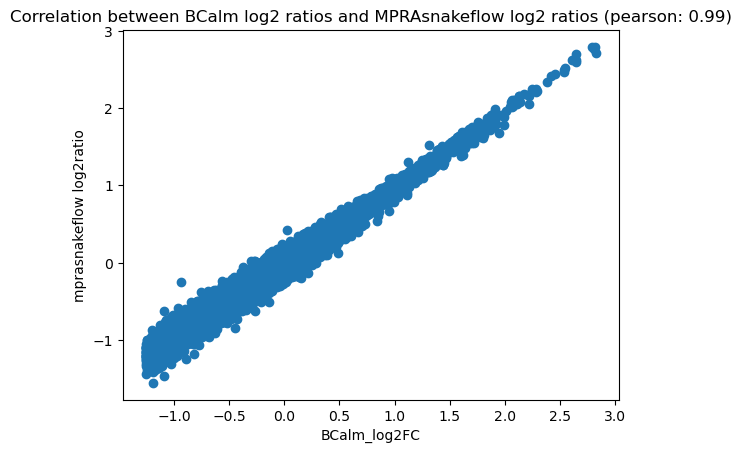

In [25]:
bcalm_result_all_elements_group_idx.head()
print('Number of elements tested: ', bcalm_result_all_elements_group_idx.shape[0])
# merge:
mprann_all_tested_regions_ratios = bcalm_result_all_elements_group_idx.merge(mprasnakeflow_ratio_df, left_on="ID", right_on="name", how='inner')

# mprann_all_tested_regions_ratios[['BIN', 'ID', 'mprasnakeflow_log2_ratio']].to_csv(config['files']['creating']['mprann_all_with_alt_mprasnakeflow_ratio'], sep="\t", index=False)

mprann_all_tested_regions_ratios_seq = mprann_all_tested_regions_ratios.merge(design_fasta, on='ID', how='inner')
# mprann_all_tested_regions_ratios_seq[['ID', 'BIN', 'sequence', 'mprasnakeflow_log2_ratio']].to_csv('/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/projects/MPRAnn/cadd_regseq_finetunig/resources/80K_all_regions_sequence_mprasnakeflow_log2_ratio.tsv', sep="\t", index=False)
mprann_all_tested_regions_ratios_seq[['ID', 'BIN', 'sequence', 'mprasnakeflow_log2_ratio']].to_csv(config['files']['creating']['deepstarr_all_with_alt_fasta_mprasnakeflow_ratios'], sep="\t", index=False)

print('Numbers should be same')
print(mprann_all_tested_regions_ratios.shape[0])
print(mprann_all_tested_regions_ratios_seq.shape[0])


# # correlation plot between REF_BCalm_logFC and log2
plt.scatter(mprann_all_tested_regions_ratios['REF_BCalm_logFC'], mprann_all_tested_regions_ratios['mprasnakeflow_log2_ratio'])
plt.xlabel('BCalm_log2FC')
plt.ylabel('mprasnakeflow log2ratio')
plt.title(f"Correlation between BCalm log2 ratios and MPRAsnakeflow log2 ratios (pearson: {round(mprann_all_tested_regions_ratios[['REF_BCalm_logFC', 'mprasnakeflow_log2_ratio']].corr(method='pearson')['mprasnakeflow_log2_ratio'].iloc[0],2)})")


### Plot and only take highly and lowly active (sanity check if the network learns)

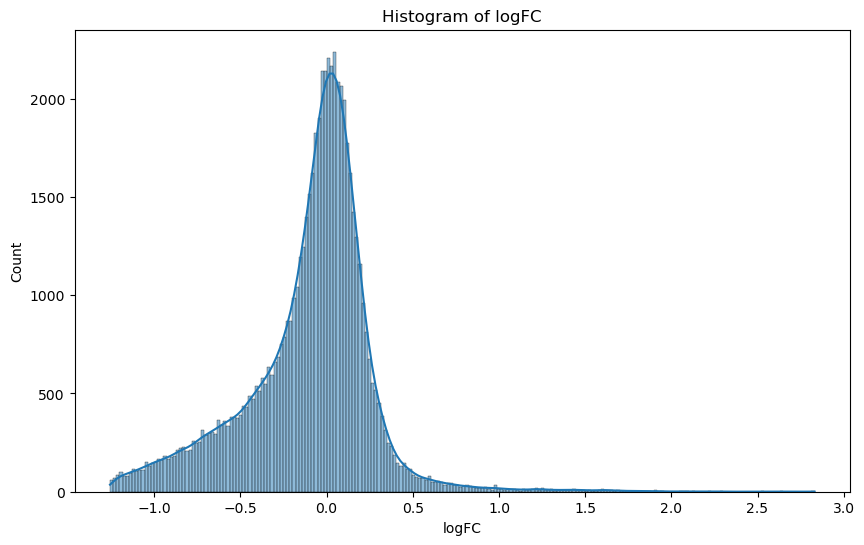

In [ ]:
import seaborn as sns
# Assuming your dataframe is called 'df' and contains a 'logFC' column
plt.figure(figsize=(10, 6))
sns.histplot(data=bcalm_result_all_elements_group_idx, x='logFC', kde=True)
plt.title('Histogram of logFC')
plt.xlabel('logFC')
plt.ylabel('Count')
plt.show()

##### Print the open regions in neuron side by side

In [ ]:
# read the bed file
open_wtc11_ngn2_atac_bed = pd.read_csv(config['files']['creating']['wtc11_ngn2_atac_tested_elements_overlap_verbose_annotation'], sep="\t", header=None)
open_wtc11_ngn2_atac_bed['is_open_neuron'] = True
open_wtc11_ngn2_atac_bed = open_wtc11_ngn2_atac_bed[[3, 'is_open_neuron']]
open_wtc11_ngn2_atac_bed.columns = ['tmp_screen_region', 'is_open_neuron']
open_wtc11_ngn2_atac_bed
bcalm_result_all_elements_group_idx.columns
open_neuron_bcalm_result_all_elements_group_idx = bcalm_result_all_elements_group_idx.merge(open_wtc11_ngn2_atac_bed, on='tmp_screen_region', how='left')
open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron'] = open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron'].fillna(False)
open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron'].value_counts()
open_neuron_bcalm_result_all_elements_group_idx.shape[0]

print(f'Mean of open neuron regions', open_neuron_bcalm_result_all_elements_group_idx.loc[open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron']]['logFC'].mean())
print(f'median of open neuron regions', open_neuron_bcalm_result_all_elements_group_idx.loc[open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron']]['logFC'].median())
print(f'Mean of not open neuron regions', open_neuron_bcalm_result_all_elements_group_idx.loc[~open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron']]['logFC'].mean())
print(f'median of not open neuron regions', open_neuron_bcalm_result_all_elements_group_idx.loc[~open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron']]['logFC'].median())

Mean of open neuron regions 0.17063367306240235
median of open neuron regions 0.132695994191748
Mean of not open neuron regions -0.10601790741078354
median of not open neuron regions -0.0338043189221147


In [ ]:
open_neuron_bcalm_result_all_elements_group_idx

,logFC,name,tmp_screen_region,tmp_gene_list,group_idx,BIN,is_open_neuron
0,2.056023,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,EH38E3192081,[WWOX],0,7,False
1,1.901706,cardiac_neuro_cava_random:RERE|ENSG00000142599...,EH38E1316374,[RERE],1,3,True
2,2.088181,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,EH38E1918401,[TCF4],2,11,False
3,2.287976,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,EH38E1880427,[PSMD12],3,6,False
4,1.768680,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,EH38E2924690,[RBM20],4,8,False
...,...,...,...,...,...,...,...
63898,-1.165619,cardiac_neuro_cava_random:VPS13B|ENSG000001325...,EH38E3847748,[VPS13B],195,10,False
63899,-1.194520,cardiac_neuro_cava_random:REF_FANCM|ENSG000001...,EH38E1711430,[FANCM],1408,11,False
63900,-1.177983,cardiac_neuro_cava_random:ALT_FTO|ENSG00000140...,EH38E1816661,[FTO],205,6,False
63901,-1.222079,cardiac_neuro_cava_random:NLGN4X|ENSG000001469...,EH38E3923797,[NLGN4X],718,7,False


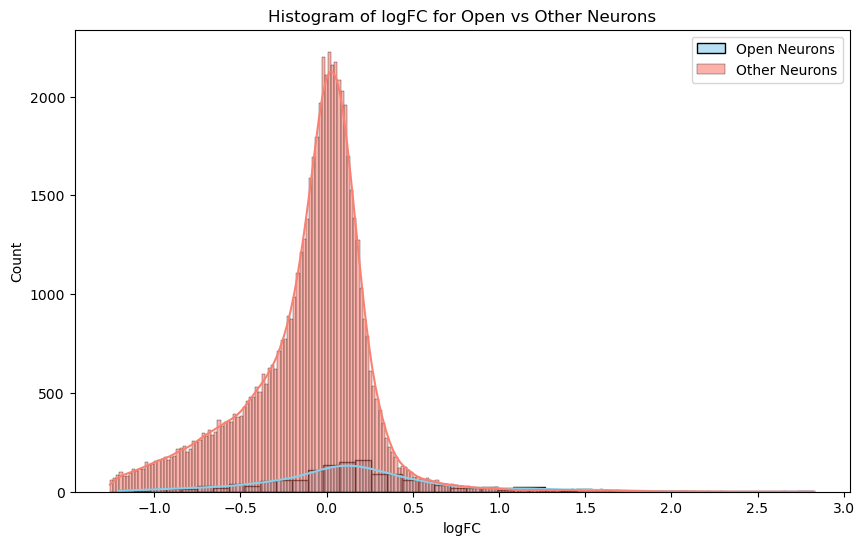

In [ ]:
plt.figure(figsize=(10, 6))

# Plot histogram for True values
sns.histplot(data=open_neuron_bcalm_result_all_elements_group_idx[open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron'] == True],
             x='logFC',
             color='skyblue',
             label='Open Neurons',
             kde=True,
             alpha=0.6)

# Plot histogram for False (or other) values
sns.histplot(data=open_neuron_bcalm_result_all_elements_group_idx[open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron'] != True],
             x='logFC',
             color='salmon',
             label='Other Neurons',
             kde=True,
             alpha=0.6)

plt.title('Histogram of logFC for Open vs Other Neurons')
plt.xlabel('logFC')
plt.ylabel('Count')
plt.legend()
plt.show()

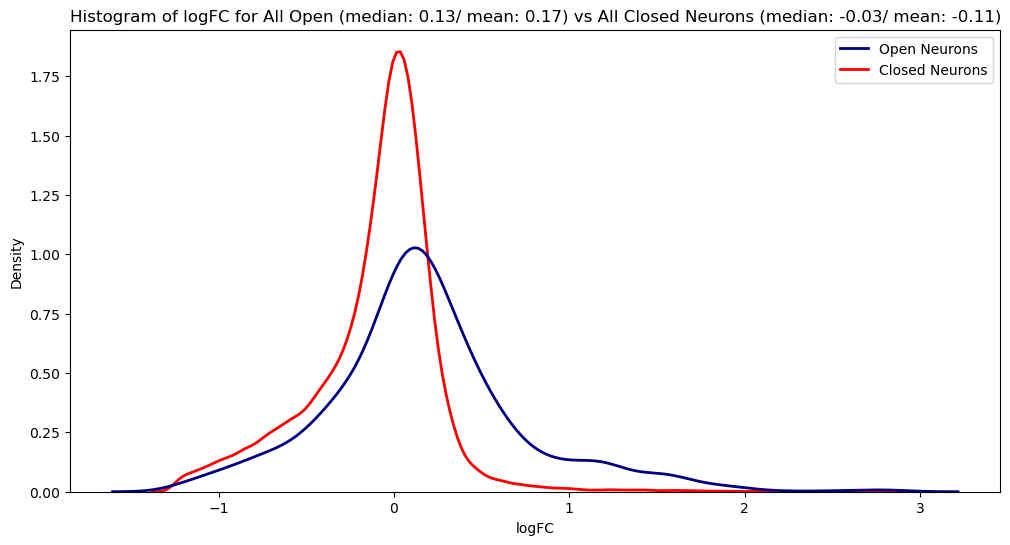

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# def sample_and_hist(data, column, n_samples=1400, bins=50):
#     sample = data[data['is_open_neuron'] == False][column].sample(n=min(n_samples, len(data[data['is_open_neuron'] == False])), replace=True)
#     hist, bin_edges = np.histogram(sample, bins=bins, density=True)
#     return hist, bin_edges

# # Number of samplings
# n_samplings = 10
# bins = 50  # Set a fixed number of bins

# # Store results for closed neurons
# all_hists_closed = []
# bin_edges = None

# for _ in range(n_samplings):
#     hist_closed, edges = sample_and_hist(open_neuron_bcalm_result_all_elements_group_idx, 'logFC', bins=bins)
#     all_hists_closed.append(hist_closed)
#     if bin_edges is None:
#         bin_edges = edges

# # Convert list to numpy array
# all_hists_closed = np.array(all_hists_closed)

# # Calculate mean and confidence intervals
# hist_mean_closed = np.mean(all_hists_closed, axis=0)
# hist_std_closed = np.std(all_hists_closed, axis=0)
# hist_ci_low_closed = hist_mean_closed - 1.96 * hist_std_closed / np.sqrt(n_samplings)
# hist_ci_high_closed = hist_mean_closed + 1.96 * hist_std_closed / np.sqrt(n_samplings)

# # Plot the mean histogram
# plt.bar(bin_edges[:-1], hist_mean_closed, width=np.diff(bin_edges), alpha=0.5, color='salmon', align='edge', label='Closed Neurons')

# # Plot the confidence interval
# plt.fill_between(bin_edges[:-1], hist_ci_low_closed, hist_ci_high_closed, color='salmon', alpha=0.3)
# Plotting
plt.figure(figsize=(12, 6))


# Add KDE plot
sns.kdeplot(data=open_neuron_bcalm_result_all_elements_group_idx[~open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron']], x='logFC', color='red', linewidth=2)
sns.kdeplot(data=open_neuron_bcalm_result_all_elements_group_idx[open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron']], x='logFC', color='navy', linewidth=2)

closed_mean = open_neuron_bcalm_result_all_elements_group_idx[~open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron']]['logFC'].mean()
open_mean = open_neuron_bcalm_result_all_elements_group_idx[open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron']]['logFC'].mean()
closed_median = open_neuron_bcalm_result_all_elements_group_idx[~open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron']]['logFC'].median()
open_median = open_neuron_bcalm_result_all_elements_group_idx[open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron']]['logFC'].median()

plt.title(f'Histogram of logFC for All Open (median: {round(open_median,2)}/ mean: {round(open_mean,2)}) vs All Closed Neurons (median: {round(closed_median,2)}/ mean: {round(closed_mean,2)})')
plt.xlabel('logFC')
plt.ylabel('Density')

# Add legend
plt.plot([], [], color='navy', linewidth=2, label='Open Neurons')
plt.plot([], [], color='red', linewidth=2, label='Closed Neurons')
plt.legend()

plt.show()

In [ ]:
open_neuron_bcalm_result_all_elements_group_idx_without_alt = open_neuron_bcalm_result_all_elements_group_idx.loc[~open_neuron_bcalm_result_all_elements_group_idx[col_name].str.contains(':ALT_')]

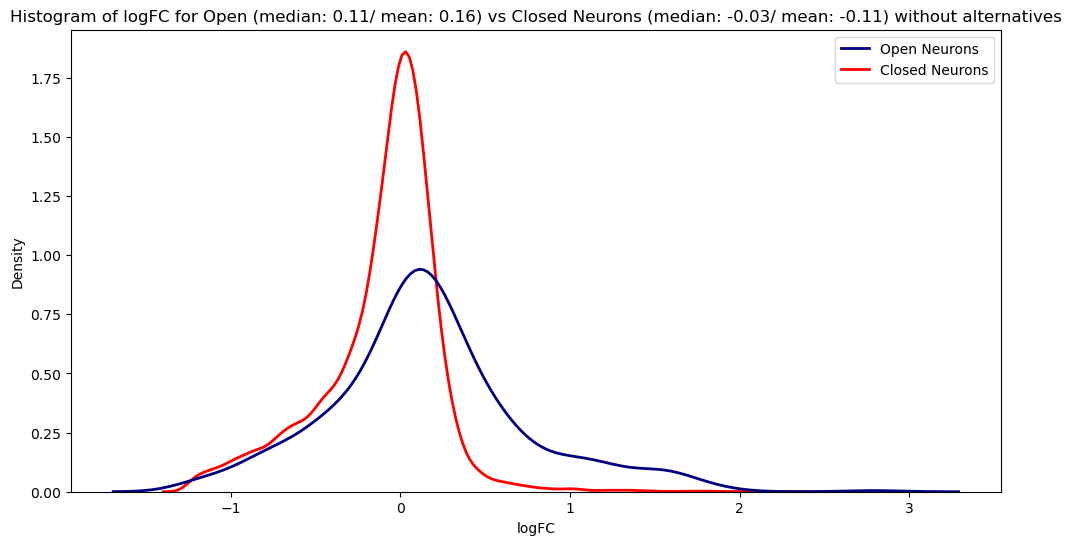

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))


# Add KDE plot
sns.kdeplot(data=open_neuron_bcalm_result_all_elements_group_idx_without_alt[~open_neuron_bcalm_result_all_elements_group_idx_without_alt['is_open_neuron']], x='logFC', color='red', linewidth=2)
sns.kdeplot(data=open_neuron_bcalm_result_all_elements_group_idx_without_alt[open_neuron_bcalm_result_all_elements_group_idx_without_alt['is_open_neuron']], x='logFC', color='navy', linewidth=2)

closed_mean = open_neuron_bcalm_result_all_elements_group_idx_without_alt[~open_neuron_bcalm_result_all_elements_group_idx_without_alt['is_open_neuron']]['logFC'].mean()
open_mean = open_neuron_bcalm_result_all_elements_group_idx_without_alt[open_neuron_bcalm_result_all_elements_group_idx_without_alt['is_open_neuron']]['logFC'].mean()
closed_median = open_neuron_bcalm_result_all_elements_group_idx_without_alt[~open_neuron_bcalm_result_all_elements_group_idx_without_alt['is_open_neuron']]['logFC'].median()
open_median = open_neuron_bcalm_result_all_elements_group_idx_without_alt[open_neuron_bcalm_result_all_elements_group_idx_without_alt['is_open_neuron']]['logFC'].median()

plt.title(f'Histogram of logFC for Open (median: {round(open_median,2)}/ mean: {round(open_mean,2)}) vs Closed Neurons (median: {round(closed_median,2)}/ mean: {round(closed_mean,2)}) without alternatives')
plt.xlabel('logFC')
plt.ylabel('Density')

# Add legend
plt.plot([], [], color='navy', linewidth=2, label='Open Neurons')
plt.plot([], [], color='red', linewidth=2, label='Closed Neurons')
plt.legend()

plt.show()

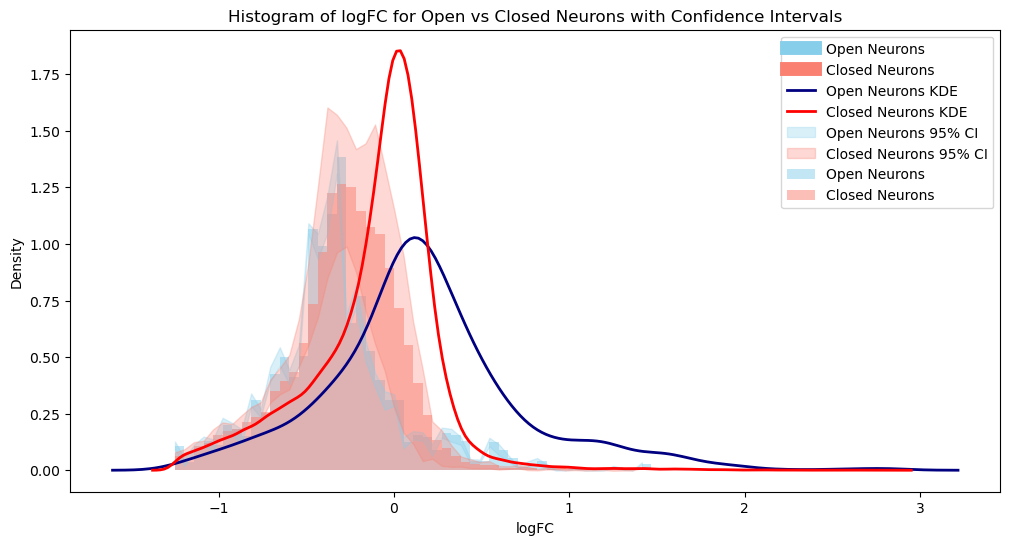

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming your dataframe is called 'df'

def sample_and_hist(data, column, is_open, n_samples=1400, bins=50):
    sample = data[data['is_open_neuron'] == is_open][column].sample(n=min(n_samples, len(data[data['is_open_neuron'] == is_open])), replace=True)
    hist, bin_edges = np.histogram(sample, bins=bins, density=True)
    return hist, bin_edges

# Number of samplings
n_samplings = 10
bins = 50  # Set a fixed number of bins

# Store results for open and closed neurons
all_hists_open = []
all_hists_closed = []
bin_edges = None

for _ in range(n_samplings):
    hist_open, edges = sample_and_hist(open_neuron_bcalm_result_all_elements_group_idx, 'logFC', True, bins=bins)
    hist_closed, edges = sample_and_hist(open_neuron_bcalm_result_all_elements_group_idx, 'logFC', False, bins=bins)
    all_hists_open.append(hist_open)
    all_hists_closed.append(hist_closed)
    if bin_edges is None:
        bin_edges = edges

# Convert lists to numpy arrays
all_hists_open = np.array(all_hists_open)
all_hists_closed = np.array(all_hists_closed)

# Calculate mean and confidence intervals
hist_mean_open = np.mean(all_hists_open, axis=0)
hist_std_open = np.std(all_hists_open, axis=0)
hist_ci_low_open = hist_mean_open - 1.96 * hist_std_open / np.sqrt(n_samplings)
hist_ci_high_open = hist_mean_open + 1.96 * hist_std_open / np.sqrt(n_samplings)

hist_mean_closed = np.mean(all_hists_closed, axis=0)
hist_std_closed = np.std(all_hists_closed, axis=0)
hist_ci_low_closed = hist_mean_closed - 1.96 * hist_std_closed / np.sqrt(n_samplings)
hist_ci_high_closed = hist_mean_closed + 1.96 * hist_std_closed / np.sqrt(n_samplings)

# Plotting
plt.figure(figsize=(12, 6))

# Plot the mean histograms
plt.bar(bin_edges[:-1], hist_mean_open, width=np.diff(bin_edges), alpha=0.5, color='skyblue', align='edge', label='Open Neurons')
plt.bar(bin_edges[:-1], hist_mean_closed, width=np.diff(bin_edges), alpha=0.5, color='salmon', align='edge', label='Closed Neurons')

# Plot the confidence intervals
plt.fill_between(bin_edges[:-1], hist_ci_low_open, hist_ci_high_open, color='skyblue', alpha=0.3)
plt.fill_between(bin_edges[:-1], hist_ci_low_closed, hist_ci_high_closed, color='salmon', alpha=0.3)

# Add KDE plots
sns.kdeplot(data=open_neuron_bcalm_result_all_elements_group_idx[open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron'] == True], x='logFC', color='navy', linewidth=2)
sns.kdeplot(data=open_neuron_bcalm_result_all_elements_group_idx[open_neuron_bcalm_result_all_elements_group_idx['is_open_neuron'] == False], x='logFC', color='red', linewidth=2)

plt.title('Histogram of logFC for Open vs Closed Neurons with Confidence Intervals')
plt.xlabel('logFC')
plt.ylabel('Density')

# Add legend
plt.plot([], [], color='skyblue', linewidth=10, label='Open Neurons')
plt.plot([], [], color='salmon', linewidth=10, label='Closed Neurons')
plt.plot([], [], color='navy', linewidth=2, label='Open Neurons KDE')
plt.plot([], [], color='red', linewidth=2, label='Closed Neurons KDE')

plt.legend()

plt.show()

In [ ]:
bcalm_result_all_element_genes['group_idx'].nunique() # 513

513

In [ ]:
group_idx_df = bcalm_result_all_element_genes[['name', 'group_idx']]

,logFC,AveExpr,t,P.Value,adj.P.Val,name,tmp_screen_region,tmp_gene_list,assigned_gene_number,seq_idx,group_idx
0,2.056023,0.798601,60.235487,4.614527e-240,2.960127e-235,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,EH38E3192081,WWOX,1,0,0
1,1.866095,0.608280,51.521602,3.647112e-194,2.599499e-190,cardiac_neuro_cava_random:ALT_WWOX|ENSG0000018...,EH38E3192081,WWOX,1,8,0
2,0.664540,-0.593182,29.899732,1.582841e-116,1.068801e-113,cardiac_neuro_cava_random:ALT_WWOX|ENSG0000018...,EH38E3192350,WWOX,1,94,0
3,0.591298,-0.666637,26.030770,5.416785e-93,1.510765e-90,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,EH38E3192350,WWOX,1,229,0
4,0.536201,-0.721488,23.500189,3.303522e-78,4.106867e-76,cardiac_neuro_cava_random:ALT_WWOX|ENSG0000018...,EH38E3192350,WWOX,1,515,0
...,...,...,...,...,...,...,...,...,...,...,...
64187,-0.280872,-1.538268,3.607304,2.026278e-04,2.547712e-04,cardiac_neuro_cava_random:REF_EEF1A2|ENSG00000...,EH38E2129369,EEF1A2,1,51018,29925
64188,-0.693293,-1.951199,0.251908,4.007240e-01,4.396833e-01,cardiac_neuro_cava_random:ALT_EEF1A2|ENSG00000...,EH38E2129369,EEF1A2,1,58442,29925
64189,-0.018529,-1.276372,4.126952,3.186221e-05,4.131756e-05,cardiac_neuro_cava_random:EEF1A2|ENSG000001012...,EH38E3448923,EEF1A2,1,49467,29925
64190,-0.498970,-1.756677,1.434428,7.684784e-02,8.761616e-02,cardiac_neuro_cava_random:ALT_EEF1A2|ENSG00000...,EH38E3448895,EEF1A2,1,56259,29925


True

In [ ]:
import pandas as pd
listone = [['a', 'b', 'c'], ['g'], ['z', 'z']]
listtwo = ['t', 't', 'h']
df = pd.DataFrame({'gene': listone, 'region': listtwo})
df['seqidx'] = df.index
df['group_idx'] = df.index
df



,gene,region,seqidx,group_idx
0,"[a, b, c]",t,0,0
1,[g],t,1,1
2,"[z, z]",h,2,2


In [ ]:
sequence_df = df.explode('gene')
sequence_df
# gene_groups = sequence_df.groupby('gene').agg(min).reset_index()
# gene_groups


,gene,region,seqidx,group_idx
0,a,t,0,0
0,b,t,0,0
0,c,t,0,0
1,g,t,1,1
2,z,h,2,2
2,z,h,2,2


In [ ]:
sequence_df.drop(columns=['group_idx'], inplace=True)
sequence_df = sequence_df.merge(gene_groups[['gene', 'group_idx']], on='gene', how='inner')
sequence_df

,gene,region,seqidx,group_idx
0,a,t,0,0
1,b,t,0,0
2,c,t,0,0
3,g,t,1,1
4,z,h,2,2
5,z,h,2,2


In [ ]:
region_groups = sequence_df.groupby('region').agg(min).reset_index()
region_groups
sequence_df.drop(columns=['group_idx'], inplace=True)
sequence_df.merge(region_groups[['region', 'group_idx']], on='region', how='inner')

,gene,region,seqidx,group_idx
0,a,t,0,0
1,b,t,0,0
2,c,t,0,0
3,g,t,1,0
4,z,h,2,2
5,z,h,2,2


In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
X = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10], [11, 12]])
y = np.array([1, 2, 3, 4, 5, 6])
groups = np.array([0, 0, 0, 1, 3, 3])
group_kfold = GroupKFold(n_splits=2)
group_kfold.get_n_splits(X, y, groups)
print(group_kfold)
for i, (train_index, test_index) in enumerate(group_kfold.split(X, y, groups)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}, group={groups[train_index]}")
    print(f"  Test:  index={test_index}, group={groups[test_index]}")

GroupKFold(n_splits=2)
Fold 0:
  Train: index=[3 4 5], group=[1 3 3]
  Test:  index=[0 1 2], group=[0 0 0]
Fold 1:
  Train: index=[0 1 2], group=[0 0 0]
  Test:  index=[3 4 5], group=[1 3 3]


In [ ]:
# bcalm_result_all_elements.loc[~bcalm_result_all_elements['same_gene']]
# get list of regions which are matching to two genes (genes need to be grouped together to prevent data leakage)

# 207 are there more cases?
bcalm_result_all_elements.loc[bcalm_result_all_elements[col_name].str.contains("~")][col_name].to_list()
bcalm_result_all_elements.loc[bcalm_result_all_elements[col_name].str.contains("~")][['name', 'tmp_gene_list']].to_csv('testing_tmp.tsv', sep="\t", index=False)


In [ ]:
bcalm_result_all_elements['tmp_second_gene_assignment']

0        None
1        None
2        None
3        None
4        None
         ... 
63328    None
63329    None
63330    None
63331    None
63332    None
Name: tmp_second_gene_assignment, Length: 63333, dtype: object

### Prepare data for Open chromatin training

In [ ]:
pls_seqs_bed = config['files']['creating']['promoter_like_sequences']
els_seqs_bed = config['files']['creating']['enhancer_like_sequences']
combined_regions = config['files']['creating']['screen_regions_dir']

!cat {pls_seqs_bed} {els_seqs_bed} | sort -k1,1 -k2,2n > {combined_regions}/open_chromatin_regions_pls_els.bed

In [ ]:
# remove the ctcf bound regions
ctcf_seqs_bed = config['files']['creating']['ctcf_bound_sequences']

!bedtools subtract -a {combined_regions}/open_chromatin_regions_pls_els.bed -b {ctcf_seqs_bed} > {combined_regions}/open_chromatin_regions_no_ctcf.bed

In [ ]:
# create negative set with negative_training_sampler https://github.com/kircherlab/negative_training_sampler/
# !cd /home/kisa/coding/80K_MPRA/external_git_repos
# !git clone https://github.com/kircherlab/negative_training_sampler.git
!pip install -e /home/kisa/coding/80K_MPRA/external_git_repos/negative_training_sampler

Obtaining file:///home/kisa/coding/80K_MPRA/external_git_repos/negative_training_sampler
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.5 MB/s eta 0:00:00
  Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.6/179.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 79.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 78.8 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.2/242.2 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.9/377.9 kB 